# Swiss Market Analytics

Explore the Swiss corporate landscape with VynCo's analytics endpoints.
This notebook produces publication-ready charts showing canton distributions,
auditor market share, company clustering, and cohort analysis.

```bash
pip install vynco matplotlib seaborn
```

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import vynco

# --- Style setup for polished figures ---
sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS = ["#1e3a5f", "#2e86ab", "#a23b72", "#f18f01", "#c73e1d",
          "#3b1f2b", "#44bba4", "#e94f37", "#393e41", "#8d6a9f"]
ACCENT = "#2e86ab"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

client = vynco.Client()
print(f"VynCo SDK v{vynco.__version__} — connected")

VynCo SDK v3.0.0 — connected


## 1. Company Distribution by Canton

Which cantons host the most companies? A horizontal bar chart reveals
the concentration of Swiss corporate registrations.

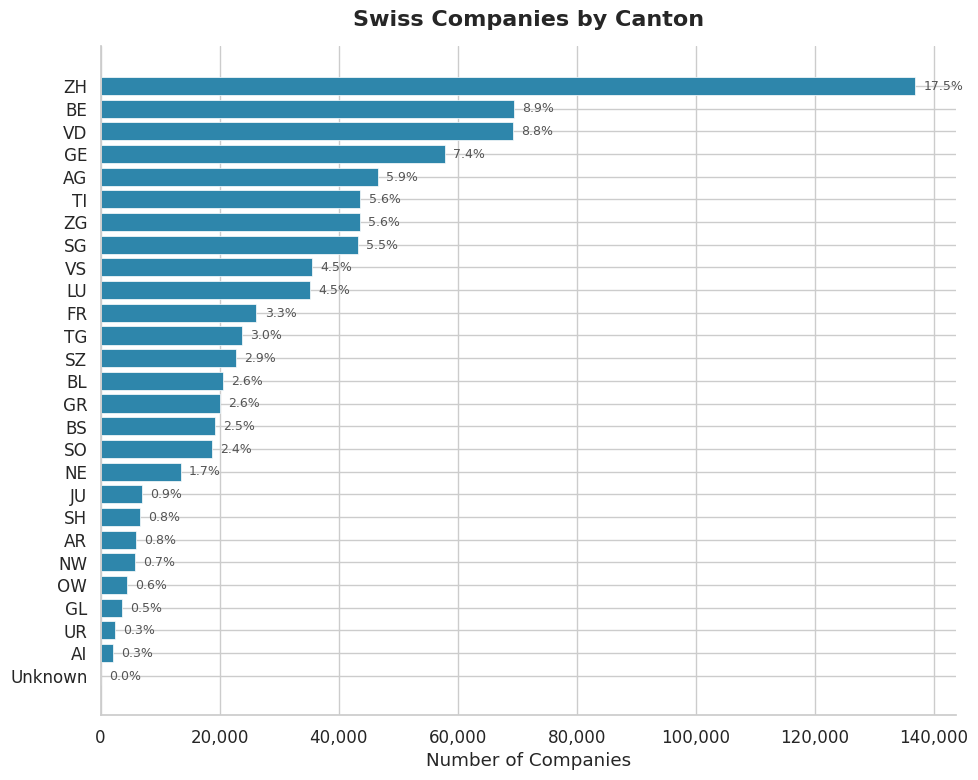

Total cantons: 27, Total companies: 784,100


In [2]:
cantons = client.analytics.cantons().data

# Sort by count descending
cantons_sorted = sorted(cantons, key=lambda c: c.count, reverse=True)
names = [c.canton for c in cantons_sorted]
counts = [c.count for c in cantons_sorted]
pcts = [c.percentage for c in cantons_sorted]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(names[::-1], counts[::-1], color=ACCENT, edgecolor="white", linewidth=0.5)

# Add percentage labels
for bar, pct in zip(bars, pcts[::-1]):
    ax.text(bar.get_width() + max(counts) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=9, color="#555")

ax.set_xlabel("Number of Companies")
ax.set_title("Swiss Companies by Canton", fontsize=16, fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/canton_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Total cantons: {len(cantons)}, Total companies: {sum(counts):,}")

## 2. Auditor Market Share

The Swiss audit market is dominated by a few large firms.
Let's visualize the top auditors and how concentrated the market is.

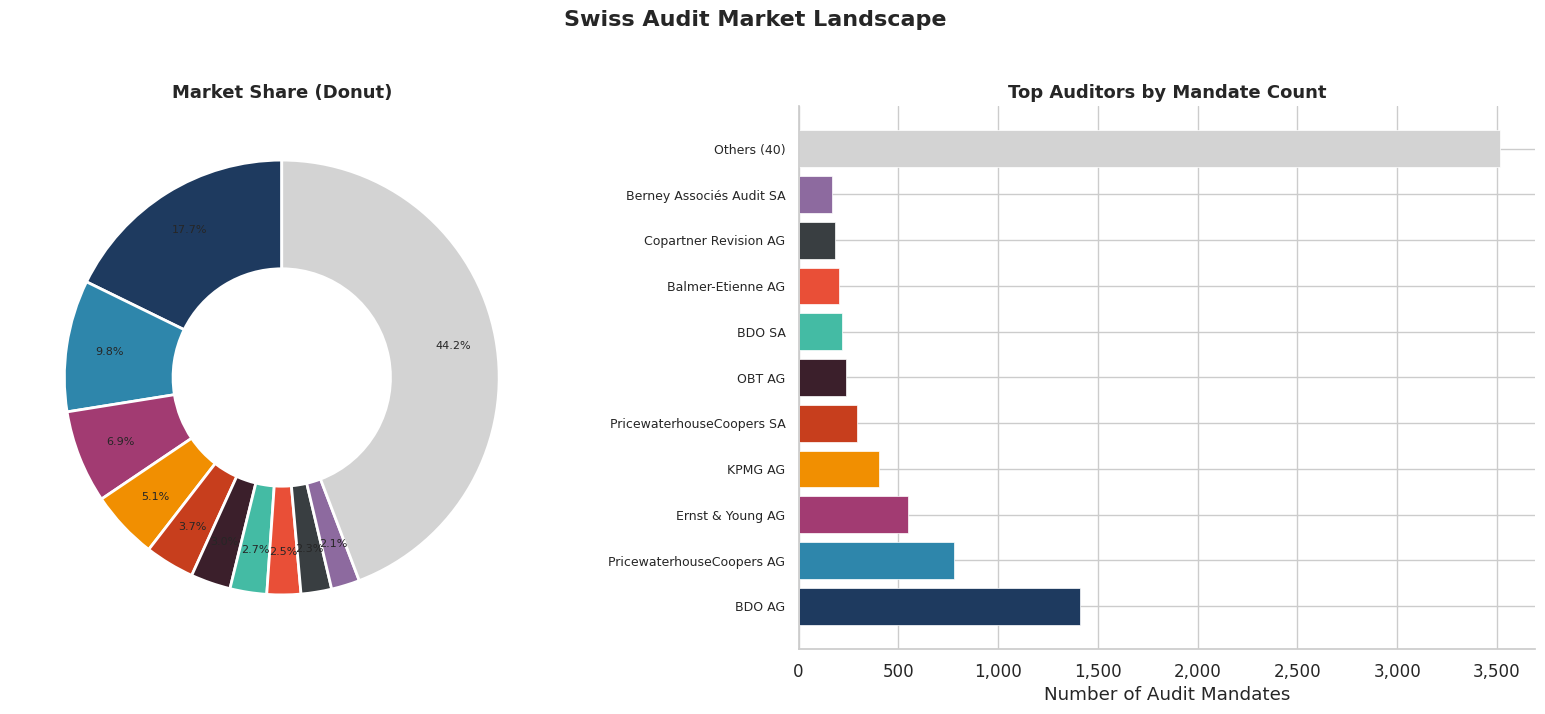

In [3]:
auditors = client.analytics.auditors().data

# Top 10 + "Others"
auditors_sorted = sorted(auditors, key=lambda a: a.company_count, reverse=True)
top_n = 10
top = auditors_sorted[:top_n]
other_count = sum(a.company_count for a in auditors_sorted[top_n:])

labels = [a.auditor_name for a in top] + [f"Others ({len(auditors_sorted) - top_n})"]
sizes = [a.company_count for a in top] + [other_count]
colors = COLORS[:top_n] + ["#d3d3d3"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1, 1.2]})

# Donut chart
wedges, texts, autotexts = ax1.pie(
    sizes, labels=None, colors=colors, autopct="%1.1f%%",
    startangle=90, pctdistance=0.8,
    wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 2}
)
for t in autotexts:
    t.set_fontsize(8)
ax1.set_title("Market Share (Donut)", fontsize=13, fontweight="bold")

# Horizontal bar chart
y_pos = range(len(labels))
ax2.barh(list(reversed(y_pos)), list(reversed(sizes)), color=list(reversed(colors)),
         edgecolor="white", linewidth=0.5)
ax2.set_yticks(list(reversed(y_pos)))
ax2.set_yticklabels(list(reversed(labels)), fontsize=9)
ax2.set_xlabel("Number of Audit Mandates")
ax2.set_title("Top Auditors by Mandate Count", fontsize=13, fontweight="bold")
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("Swiss Audit Market Landscape", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/auditor_market_share.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Company Statistics Overview

A dashboard-style view of the overall database: status breakdown,
legal forms, and canton heatmap.

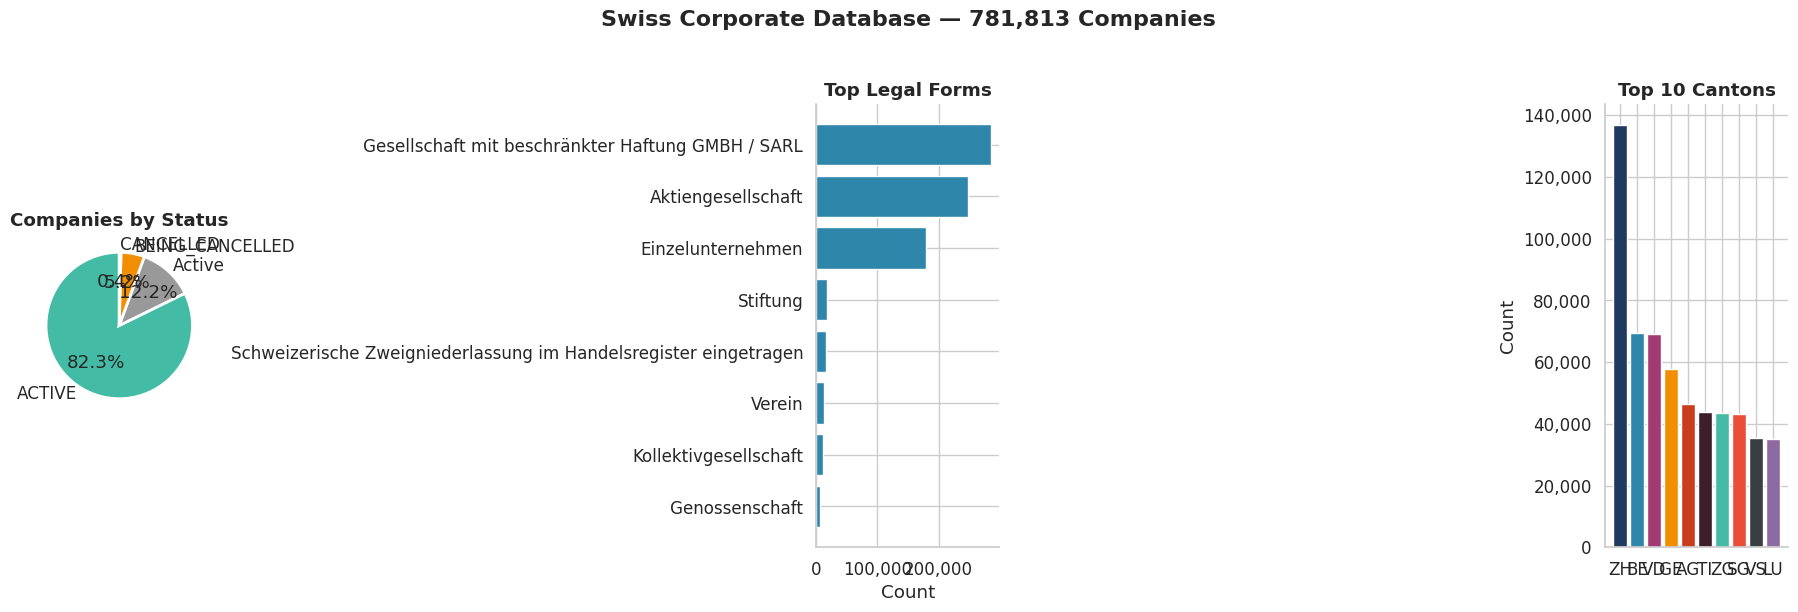

In [4]:
stats = client.companies.statistics().data

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Status breakdown
status_items = sorted(stats.by_status.items(), key=lambda x: -x[1])
s_labels = [s[0] for s in status_items]
s_values = [s[1] for s in status_items]
status_colors = {"ACTIVE": "#44bba4", "CANCELLED": "#e94f37", "BEING_CANCELLED": "#f18f01"}
s_colors = [status_colors.get(l, "#999") for l in s_labels]
axes[0].pie(s_values, labels=s_labels, colors=s_colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Companies by Status", fontweight="bold")

# 2) Top legal forms
lf_items = sorted(stats.by_legal_form.items(), key=lambda x: -x[1])[:8]
lf_labels = [l[0] for l in lf_items]
lf_values = [l[1] for l in lf_items]
axes[1].barh(lf_labels[::-1], lf_values[::-1], color=ACCENT, edgecolor="white")
axes[1].set_xlabel("Count")
axes[1].set_title("Top Legal Forms", fontweight="bold")
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[1].spines[["top", "right"]].set_visible(False)

# 3) Canton top 10
ct_items = sorted(stats.by_canton.items(), key=lambda x: -x[1])[:10]
ct_labels = [c[0] for c in ct_items]
ct_values = [c[1] for c in ct_items]
axes[2].bar(ct_labels, ct_values, color=COLORS[:10], edgecolor="white")
axes[2].set_ylabel("Count")
axes[2].set_title("Top 10 Cantons", fontweight="bold")
axes[2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[2].spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Swiss Corporate Database — {stats.total:,} Companies",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/company_statistics.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Cohort Analysis

Group companies by canton and industry to see how the
Swiss corporate landscape is distributed.

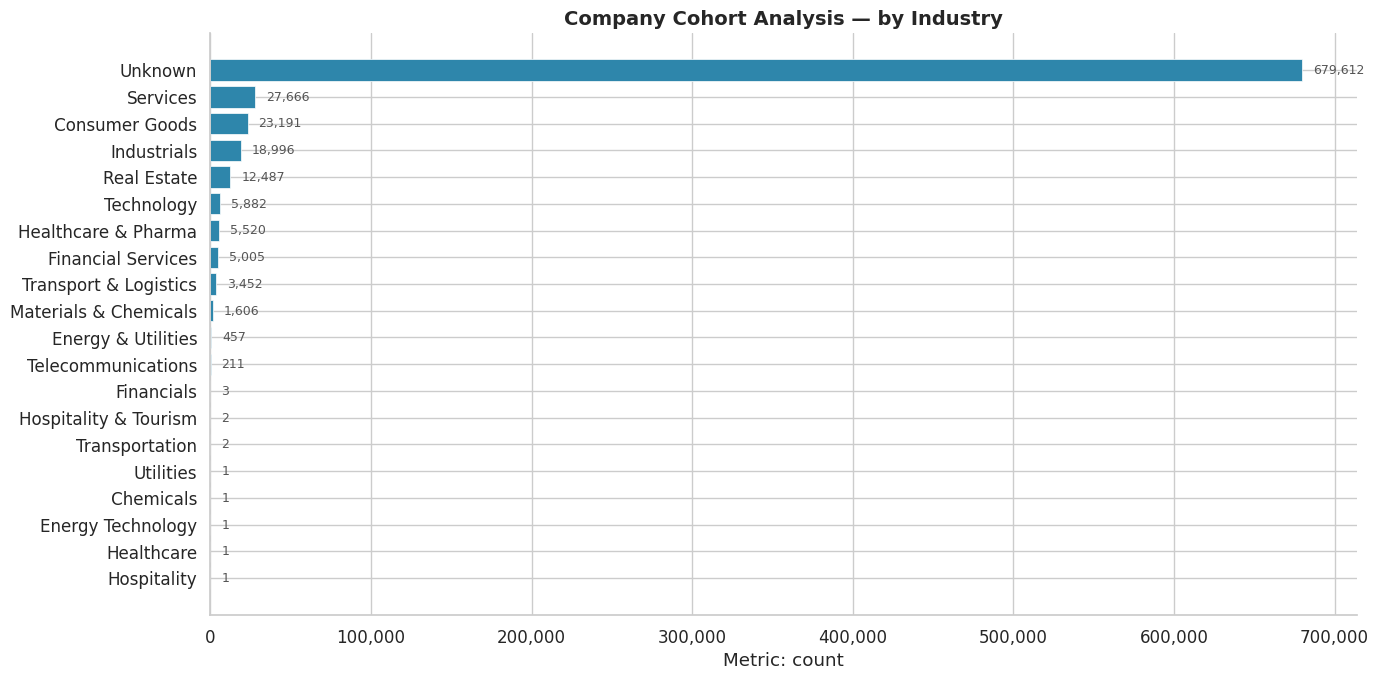

In [5]:
cohorts = client.analytics.cohorts(group_by="industry", metric="count").data

# Sort by count and take top 20 for readability
sorted_cohorts = sorted(cohorts.cohorts, key=lambda c: c.count, reverse=True)[:20]
groups = [c.group for c in sorted_cohorts]
values = [c.count for c in sorted_cohorts]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(groups[::-1], values[::-1], color=ACCENT, edgecolor="white", linewidth=0.5)

# Add count labels
for bar, val in zip(bars, values[::-1]):
    ax.text(bar.get_width() + max(values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=9, color="#555")

ax.set_xlabel(f"Metric: {cohorts.metric}")
ax.set_title(f"Company Cohort Analysis — by {cohorts.group_by.title()}",
             fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cohort_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. RFM Segmentation

Recency-Frequency-Monetary segmentation applied to Swiss companies —
a common technique for identifying company activity patterns.

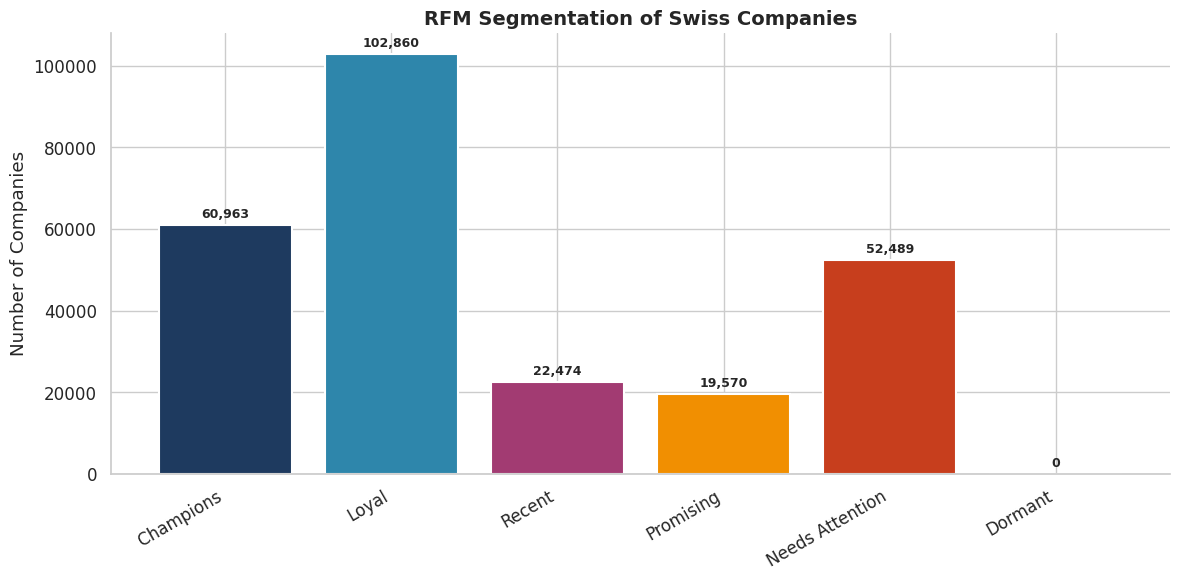

Segment descriptions:
  Champions: Recent activity, high change frequency. Most dynamic companies.
  Loyal: High frequency or high capital. Consistently active companies.
  Recent: Recent changes but lower frequency. Newly active companies.
  Promising: Moderate recency and frequency. Potential growth candidates.
  Needs Attention: Were active but activity has slowed. May need monitoring.
  Dormant: Low activity across all dimensions. Stable or inactive.


In [6]:
rfm = client.analytics.rfm_segments().data

seg_names = [s.name for s in rfm.segments]
seg_counts = [s.count for s in rfm.segments]
seg_descs = [s.description for s in rfm.segments]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(seg_names, seg_counts, color=COLORS[:len(seg_names)],
              edgecolor="white", linewidth=1.5)

# Add count labels on bars
for bar, count in zip(bars, seg_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(seg_counts) * 0.01,
            f"{count:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylabel("Number of Companies")
ax.set_title("RFM Segmentation of Swiss Companies", fontsize=14, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/rfm_segments.png", dpi=150, bbox_inches="tight")
plt.show()

# Print segment descriptions
print("Segment descriptions:")
for name, desc in zip(seg_names, seg_descs):
    print(f"  {name}: {desc}")

## 6. Legal Form Distribution

Another cohort view: how companies distribute across legal form categories.

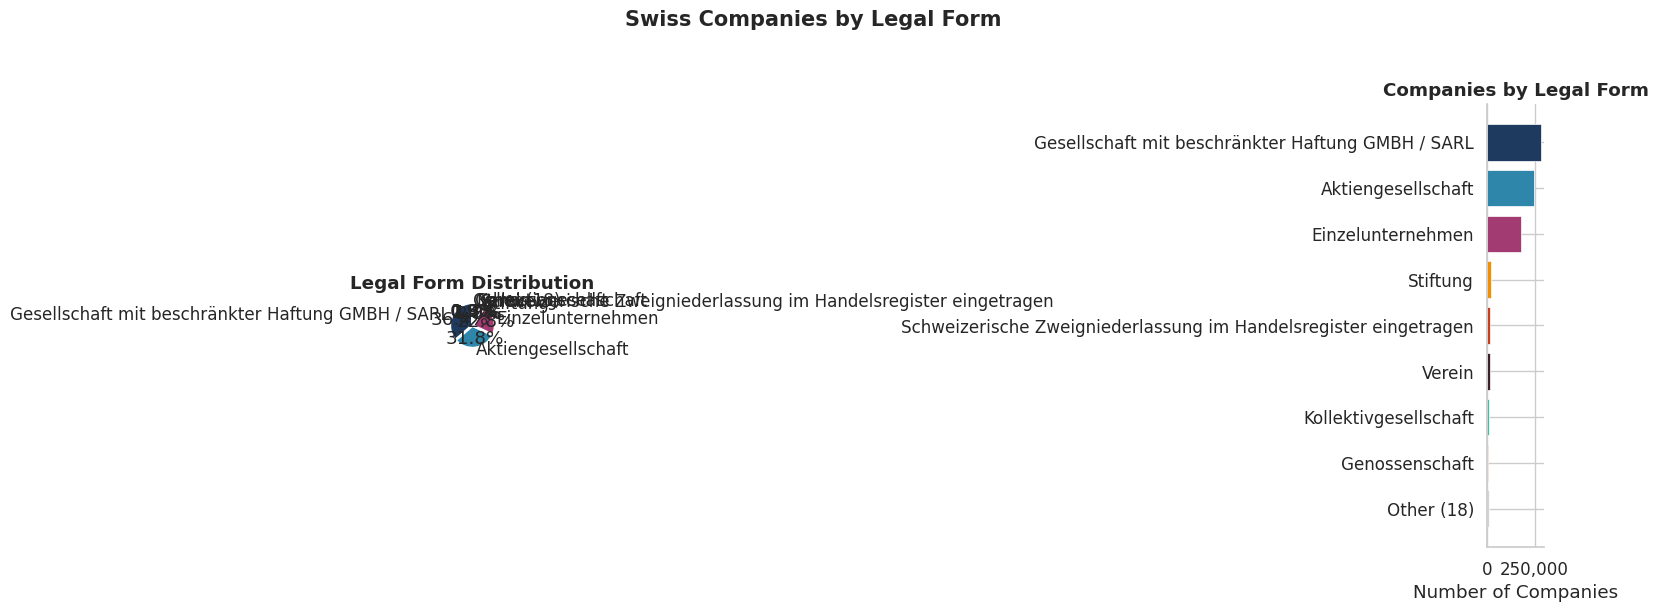

In [7]:
lf_cohorts = client.analytics.cohorts(group_by="legalForm", metric="count").data

sorted_lf = sorted(lf_cohorts.cohorts, key=lambda c: c.count, reverse=True)
lf_names = [c.group for c in sorted_lf]
lf_values = [c.count for c in sorted_lf]

# Take top 8 and group the rest as "Other"
top_n = 8
top_names = lf_names[:top_n]
top_values = lf_values[:top_n]
other_val = sum(lf_values[top_n:])
if other_val > 0:
    top_names.append(f"Other ({len(lf_names) - top_n})")
    top_values.append(other_val)

pie_colors = COLORS[:len(top_names) - 1] + ["#d3d3d3"] if other_val > 0 else COLORS[:len(top_names)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.pie(top_values, labels=top_names, colors=pie_colors, autopct="%1.1f%%",
        startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
ax1.set_title("Legal Form Distribution", fontweight="bold")

ax2.barh(top_names[::-1], top_values[::-1], color=pie_colors[::-1],
         edgecolor="white", linewidth=0.5)
ax2.set_xlabel("Number of Companies")
ax2.set_title("Companies by Legal Form", fontweight="bold")
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("Swiss Companies by Legal Form", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/legal_form_distribution.png", dpi=150, bbox_inches="tight")
plt.show()